In [1]:
!git clone https://github.com/amazon-science/patchcore-inspection.git
%cd patchcore-inspection

Cloning into 'patchcore-inspection'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 365 (delta 13), reused 8 (delta 8), pack-reused 329 (from 1)
Receiving objects: 100% (365/365), 2.02 MiB | 25.54 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Filtering content: 100% (360/360), 2.14 GiB | 48.42 MiB/s, done.
/content/patchcore-inspection


In [2]:
!pip install -q faiss-gpu-cu12
!pip install -q click pretrainedmodels scikit-image scikit-learn scipy tqdm psutil pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import torch, faiss
print(torch.__version__)
print(torch.cuda.is_available())
print(faiss.__version__)

2.11.0+cu128
True
1.14.1


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
datapath = "/content/drive/MyDrive/anormaly_detection/mvtec"

In [10]:
!PYTHONPATH=src python bin/run_patchcore.py \
--gpu 0 \
--seed 0 \
--save_patchcore_model \
--save_segmentation_images \
results \
patch_core \
-b wideresnet50 \
-le layer2 \
-le layer3 \
--pretrain_embed_dimension 1024 \
--target_embed_dimension 1024 \
--anomaly_scorer_num_nn 1 \
--patchsize 3 \
sampler \
-p 0.1 approx_greedy_coreset \
dataset \
--resize 256 \
--imagesize 224 \
-d bottle \
mvtec /content/drive/MyDrive/anormaly_detection/mvtec

INFO:__main__:Command line arguments: bin/run_patchcore.py --gpu 0 --seed 0 --save_patchcore_model --save_segmentation_images results patch_core -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1024 --target_embed_dimension 1024 --anomaly_scorer_num_nn 1 --patchsize 3 sampler -p 0.1 approx_greedy_coreset dataset --resize 256 --imagesize 224 -d bottle mvtec /content/drive/MyDrive/anormaly_detection/mvtec
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:__main__:Evaluating dataset [mvtec_bottle] (1/1)...
/usr/local/lib/python3.12/dist-packages/t

83
results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_broken_small_002.png


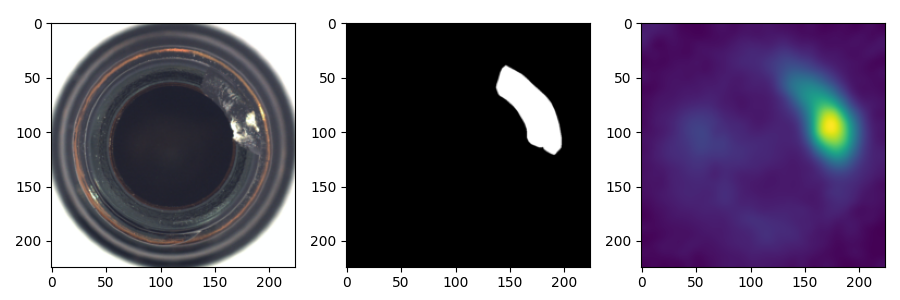

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_broken_large_000.png


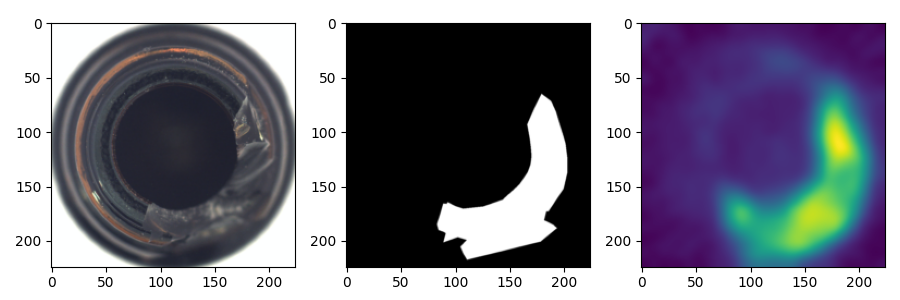

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_good_016.png


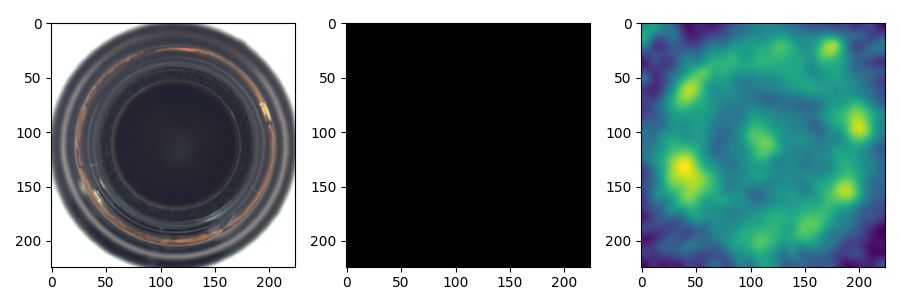

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_broken_large_010.png


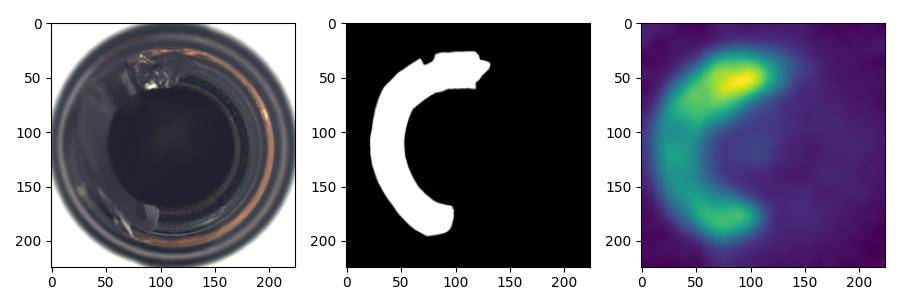

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_broken_small_010.png


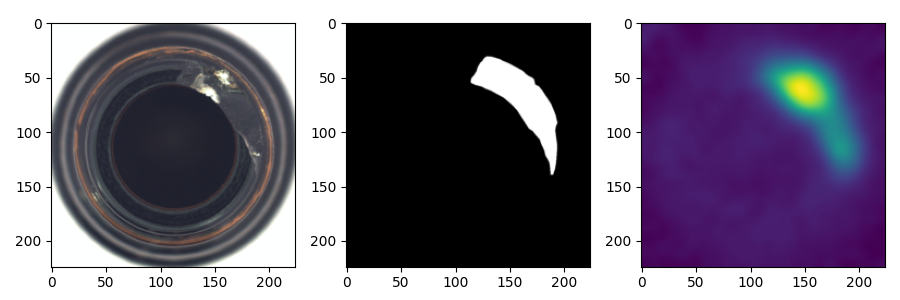

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_broken_large_014.png


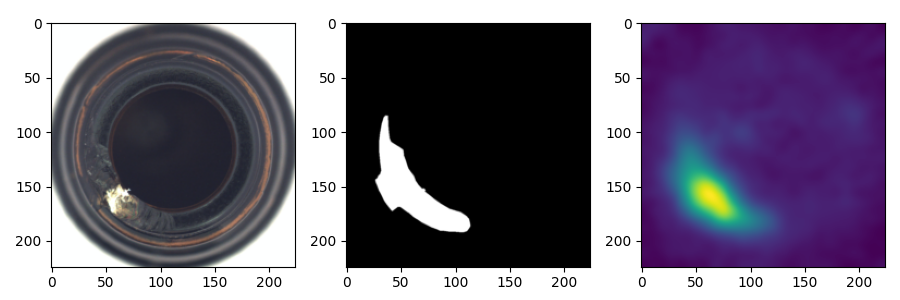

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_good_009.png


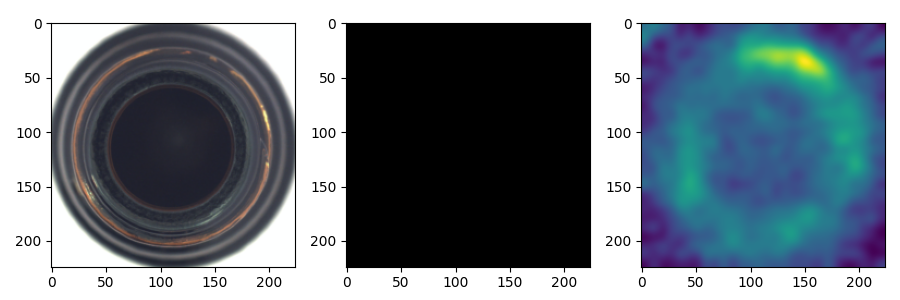

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_broken_large_017.png


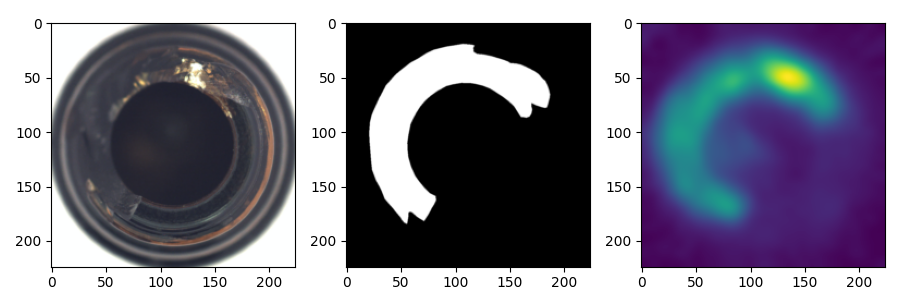

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_contamination_008.png


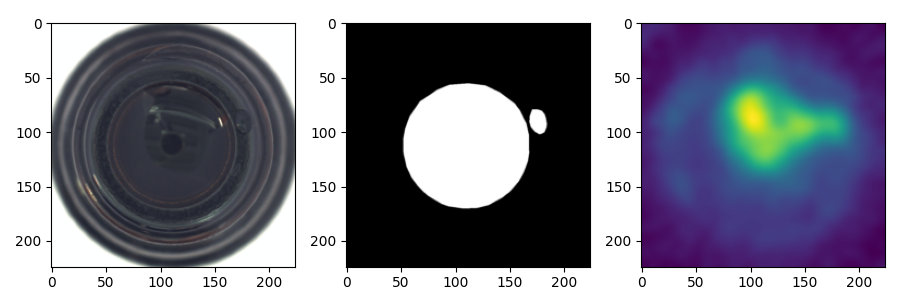

results/project/group_0/segmentation_images/mvtec_bottle/bottle_test_contamination_013.png


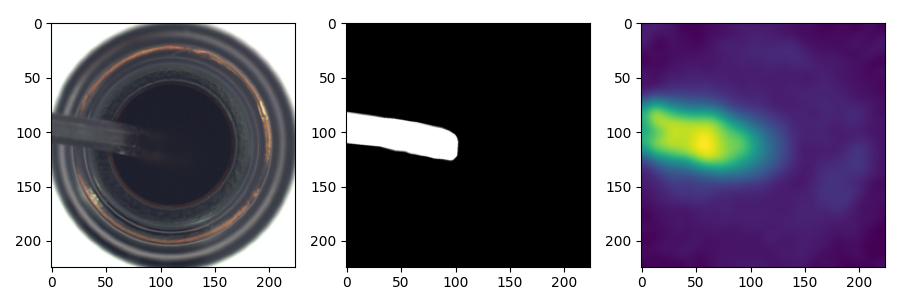

In [11]:
from IPython.display import Image, display
import glob

imgs = glob.glob("results/**/*.png", recursive=True)
print(len(imgs))

for img in imgs[:10]:
    print(img)
    display(Image(filename=img))

## Appendix: Profiling & Efficiency Study

In [12]:
import os
drive_script_path = "/content/drive/MyDrive/profile_baseline.py"
colab_script_path = "bin/profile_baseline.py"

if os.path.exists(drive_script_path):
    !cp {drive_script_path} {colab_script_path}
    print("성공적으로 Google Drive에서 profile_baseline.py 파일을 복사하였습니다!")
else:
    print(f"드라이브 경로에 파일이 존재하지 않습니다: {drive_script_path}")
    print("왼쪽 파일 탐색기에서 bin/ 디렉토리 내에 직접 profile_baseline.py 파일을 만들어 아래 코드를 붙여넣어주세요.")

성공적으로 Google Drive에서 profile_baseline.py 파일을 복사하였습니다!


In [16]:
CATEGORY = "bottle"
import torch
!PYTHONPATH=src python bin/profile_baseline.py \
    --gpu 0 \
    --seed 0 \
    results_profile \
    patch_core \
    -b wideresnet50 \
    -le layer2 \
    -le layer3 \
    --pretrain_embed_dimension 1024 \
    --target_embed_dimension 1024 \
    --anomaly_scorer_num_nn 1 \
    --patchsize 3 \
    sampler \
    -p 0.1 approx_greedy_coreset \
    dataset \
    --resize 256 \
    --imagesize 224 \
    -d {CATEGORY} \
    mvtec /content/drive/MyDrive/anormaly_detection/mvtec

INFO:__main__:Command line arguments: bin/profile_baseline.py --gpu 0 --seed 0 results_profile patch_core -b wideresnet50 -le layer2 -le layer3 --pretrain_embed_dimension 1024 --target_embed_dimension 1024 --anomaly_scorer_num_nn 1 --patchsize 3 sampler -p 0.1 approx_greedy_coreset dataset --resize 256 --imagesize 224 -d bottle mvtec /content/drive/MyDrive/anormaly_detection/mvtec
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
INFO:__main__:Evaluating dataset [mvtec_bottle] (1/1)...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWa